# Plot Spects focusing on Correct vs Incorrect

For Load-3 model

Here, we're interested in comparing correct vs incorrect trials
- analyzing data from `get_IPSCs_match_correct.m` from 1 model first


In [1]:
import numpy as np 
from matplotlib import pyplot as plt 
import os
import sys
import importlib
import scipy.io
from collections import defaultdict

# import utils path
sys.path.append('/home/nuttidalab/Documents/spikeRNN/analysis_code/utils/')
import spect_utils as su 
from bootstrap_method import *

## Load IPSCs, plot spects and band powers

In [2]:
task_load = 3
n_neurons = 400
delay = 100

proj_dir = '/home/nuttidalab/Documents/spikeRNN/'
ipsc_dir = proj_dir + f'models/letters/load_{task_load}/IPSCs/'
model_dir = proj_dir + f'models/letters/load_{task_load}/'

# get all model IPSC files and model files
model_fnames = [f for f in os.listdir(model_dir) if os.path.isfile(os.path.join(model_dir, f))]
print(f'Found {len(model_fnames)} model files')

Found 30 model files


### Are models biased in match vs mismatch?

In [3]:
# get performance in match and mismatch trials for all models

# get all model IPSC files and model files
match_perf = []
mismatch_perf = []
for i, model_fname in enumerate(model_fnames):
    # print(f'Processing {model_fname} ({i+1}/{len(model_fnames)})')

    # Get IPSC filename and load
    model_ipsc_fname = f'IPSC_match_correct_delay{delay}_nonorm_{model_fname}'  # no normalization
    model_ipsc = scipy.io.loadmat(ipsc_dir + model_ipsc_fname)
    perf = np.squeeze(model_ipsc['perf'])
    labels = np.squeeze(model_ipsc['labels'])

    match_perf.append(np.nanmean(perf[labels == 1]))
    mismatch_perf.append(np.nanmean(perf[labels == -1]))

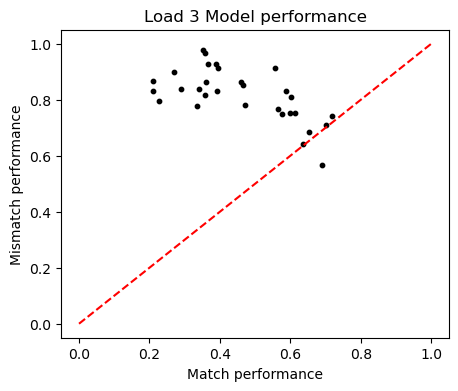

In [4]:
plt.figure(figsize=(5,4))
plt.scatter(match_perf, mismatch_perf, s=10, c='k')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('Match performance')
plt.ylabel('Mismatch performance')
plt.title('Load 3 Model performance')
plt.show()

### Split up by correct vs incorrect (still separate match vs mismatch)

#### within 1 model

In [34]:
# get correct and incorrect trials

importlib.reload(su)

# Initialize dictionaries to hold the data for each condition
# spect_data = {}
spect_data = defaultdict(lambda: defaultdict(list))

for i, model_fname in enumerate(model_fnames):
    print(f'Processing {model_fname} ({i+1}/{len(model_fnames)})')

    # Get IPSC filename and load
    # check if file exists first
    if not os.path.isfile(ipsc_dir + f'IPSC_match_correct_delay{delay}_nonorm_{model_fname}'):
        print(f"IPSC file does not exist. Skipping") # {ipsc_dir + f'IPSC_match_correct_delay{delay}_nonorm_{model_fname}'} 
        continue
    model_ipsc_fname = f'IPSC_match_correct_delay{delay}_nonorm_{model_fname}'  # no normalization
    model_ipsc = scipy.io.loadmat(ipsc_dir + model_ipsc_fname)
    perf = np.squeeze(model_ipsc['perf'])
    labels = np.squeeze(model_ipsc['labels'])
    ipscs = model_ipsc['ipscs_all']
    
    fs_ds = 1000

    # # Get exc/inh indices
    # temp = scipy.io.loadmat(model_dir + model_fname, variable_names=['exc', 'inh'])
    # exc_ind = np.where(temp['exc'] == 1)[0]
    # inh_ind = np.where(temp['inh'] == 1)[0]
    # del temp

    # Spect params
    nperseg = int(.100*fs_ds) # 100 ms
    noverlap = nperseg // 1.2
    nfft = nperseg * 20

    neur_label = ['exc', 'inh']

    for j, match in enumerate([1, -1]):
        for k, corr in enumerate([1, 0]):
            for l, neur_idx in enumerate([0, 1]): # 0 exc, 1 inh
                ipscs_neur = np.squeeze(ipscs[:,neur_idx,:])
                f, t, s = su.calc_spect(ipscs_neur[(labels == match) & (perf == corr), :], fs_ds, nperseg, noverlap, nfft)
                del ipscs_neur

                if s.shape[0] == 0:
                    print(f"No data for match={match}, corr={corr}, neur = {neur_label[l]}")
                    continue  # Skip to the next iteration if no data is found

                print(f"match={match}, corr={corr}, neur = {neur_label[l]}, n_trials = {s.shape[0]}")

                # save the s in the dictionary
                spect_data[(match, corr, neur_label[l])] = s
                
                

#                 s_mean = np.nanmean(s, axis=0) # avg over trials
#                 bandpower, _ = su.calc_band_power(10*np.log(s_mean), f, band='all')
#                 del s, s_mean

                # # Append the computed bandpower to the corresponding lists in the dictionary
                # for key in bandpower:
                #     spect_data[(match, corr, neur_label[l])][key].append(bandpower[key])
                # del bandpower

# # Now, we put all spects arrays into the same dictionary with the same keys as before
# all_spects = {}

# # For each condition (match, corr, exc/inh), stack the bandpower arrays for each key
# for key in spect_data:
#     all_spects[key] = {}
#     for sub_key in spect_data[key]:
#         all_spects[key][sub_key] = np.vstack(spect_data[key][sub_key])

# # Print the shapes of the all_spects arrays for each key
# for key, sub_dict in all_spects.items():
#     for sub_key, arr in sub_dict.items():
#         print(f"{key} -> {sub_key}: {arr.shape}")


Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_054931.mat (1/30)
IPSC file does not exist. Skipping
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_134828.mat (2/30)
IPSC file does not exist. Skipping
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_205654.mat (3/30)
IPSC file does not exist. Skipping
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_011120.mat (4/30)
IPSC file does not exist. Skipping
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_160950.mat (5/30)
IPSC file does not exist. Skipping
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_05_141900.mat (6/30)
IPSC file does not exist. Skipping
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_05_150729.mat (7/30)
IPSC file does not exist. Skipping
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_025720.mat (8/30)
IPSC file does not exist. Skipping
Processing Task_letters_N_400_Taus_4.0_2

In [35]:
# Print the shapes of the all_spects arrays for each key
for key, item in spect_data.items():
    print(key)
    print(item.shape)

(1, 1, 'exc')
(552, 1001, 110)
(1, 1, 'inh')
(552, 1001, 110)
(1, 0, 'exc')
(648, 1001, 110)
(1, 0, 'inh')
(648, 1001, 110)
(-1, 1, 'exc')
(1037, 1001, 110)
(-1, 1, 'inh')
(1037, 1001, 110)
(-1, 0, 'exc')
(163, 1001, 110)
(-1, 0, 'inh')
(163, 1001, 110)


In [15]:
# get timing info
settings = {
    'T': model_ipsc['T'][0][0],
    'delay': model_ipsc['delay'][0][0],
    'stim_on': model_ipsc['stim_on'][0][0]-1, # -1 to make it 0-indexed
    'stim_dur': model_ipsc['stim_dur'][0][0],
    'probe_dur': model_ipsc['probe_dur'][0][0],
}

fs_rate = 200
fs_ds = 1000

T = int(settings['T']/fs_rate*fs_ds)
stim_on = int(settings['stim_on']/fs_rate*fs_ds)
stim_off = int((settings['stim_on'] + settings['stim_dur'])/fs_rate*fs_ds)
probe_on = int((settings['stim_on'] + settings['stim_dur'] + settings['delay'])/fs_rate*fs_ds)
response_on = int((settings['stim_on'] + settings['stim_dur'] + settings['delay'] + 10)/fs_rate*fs_ds)

In [20]:
spect_data[(1, 1, 'exc')].shape

(552, 1001, 110)

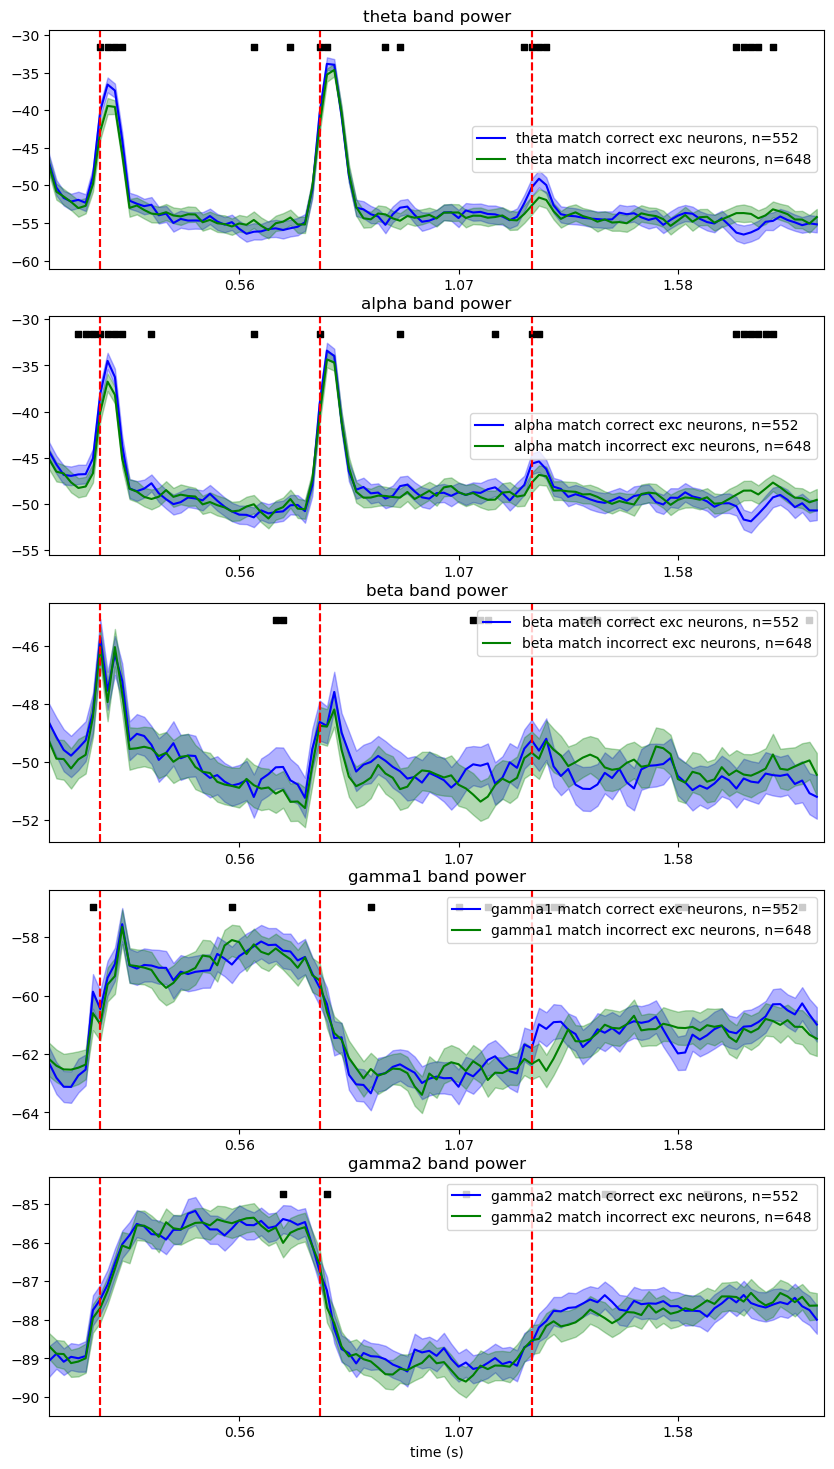

In [28]:
# get match, correct vs incorrect (exc)
importlib.reload(su)
band_avg, band_err, band_pdiff = su.compare_two_spect_groups_bootstrap(f, t, 10*np.log(spect_data[(1, 1, 'exc')]), 10*np.log(spect_data[(1, 0, 'exc')]),
            stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, 
            t_skip=30, f_skip=10, 
            neur1_label=f'match correct exc neurons, n={spect_data[(1,1,"exc")].shape[0]}', 
            neur2_label=f'match incorrect exc neurons, n={spect_data[(1,0,"exc")].shape[0]}',
            nboot = 1000, CI_int = (2.5, 97.5), random_seed = 820, title=[],
            p_sig = 0.05, band_range = [], time_range = [(stim_on/2)/fs_ds, np.nan])

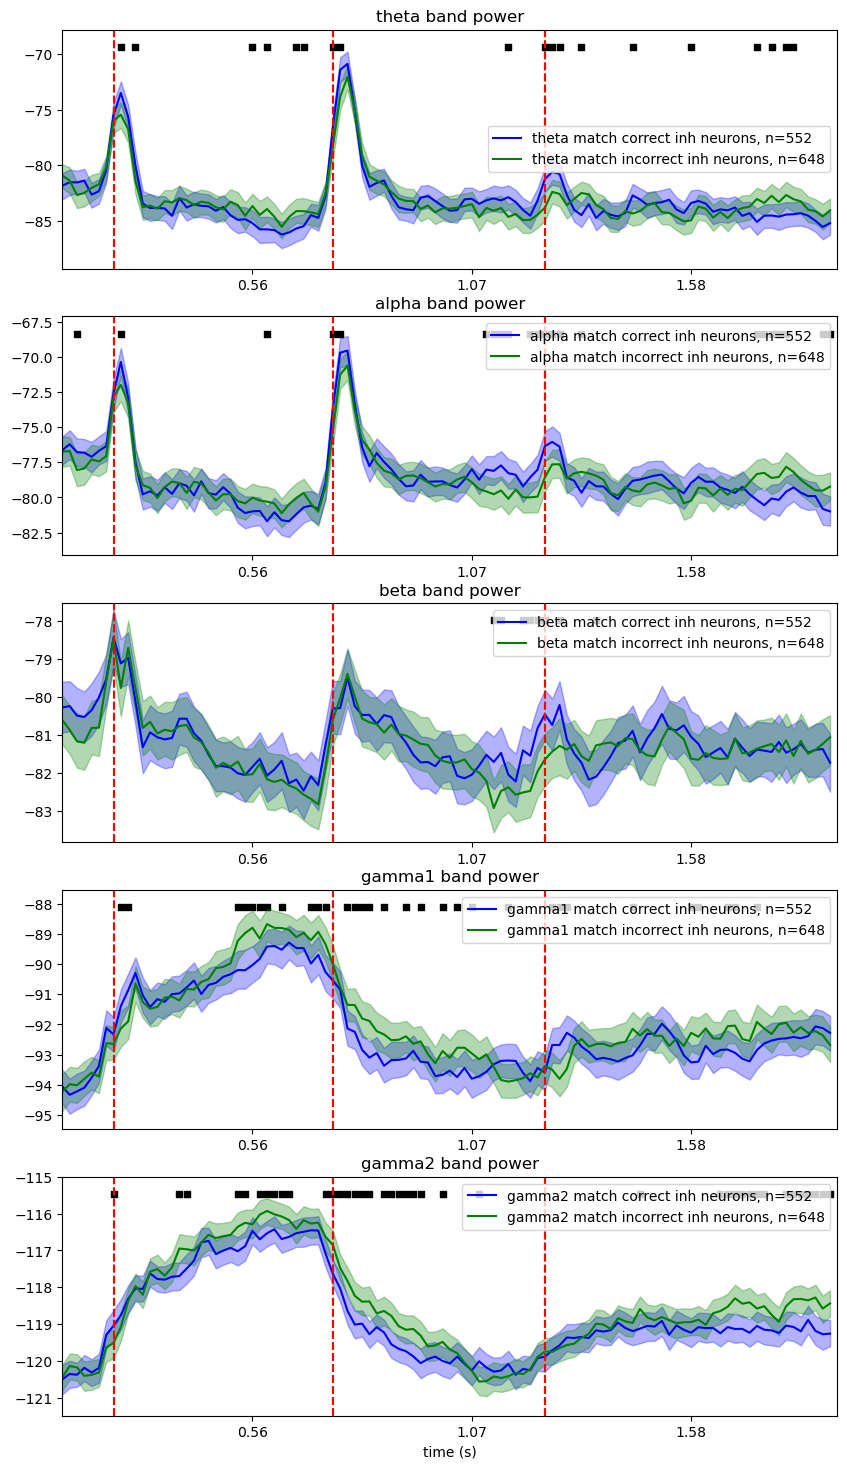

In [29]:
# get match, correct vs incorrect (inh)

band_avg, band_err, band_pdiff = su.compare_two_spect_groups_bootstrap(f, t, 10*np.log(spect_data[(1, 1, 'inh')]), 10*np.log(spect_data[(1, 0, 'inh')]),
            stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, 
            t_skip=30, f_skip=10, 
            neur1_label=f'match correct inh neurons, n={spect_data[(1,1,"inh")].shape[0]}', 
            neur2_label=f'match incorrect inh neurons, n={spect_data[(1,0,"inh")].shape[0]}',
            nboot = 1000, CI_int = (2.5, 97.5), random_seed = 820, title=[],
            p_sig = 0.05, band_range = [], time_range = [(stim_on/2)/fs_ds, np.nan])

In [37]:
spect_data[(0, 1, 'exc')]

defaultdict(list, {})

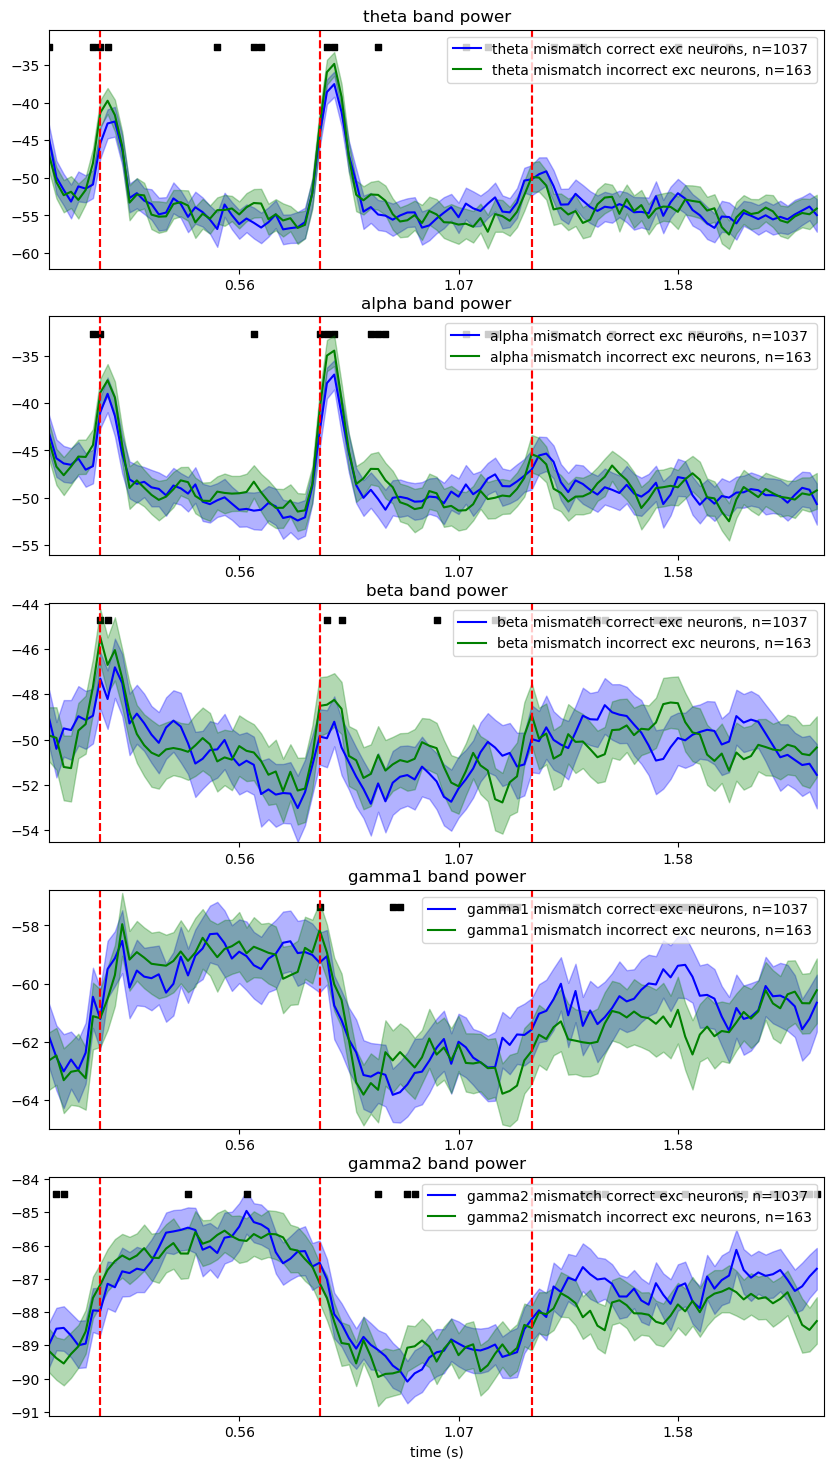

In [38]:
# get mismatch, correct vs incorrect (exc)

importlib.reload(su)
band_avg, band_err, band_pdiff = su.compare_two_spect_groups_bootstrap(f, t, 10*np.log(spect_data[(-1, 1, 'exc')]), 10*np.log(spect_data[(-1, 0, 'exc')]),
            stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, 
            t_skip=30, f_skip=10, 
            neur1_label=f'mismatch correct exc neurons, n={spect_data[(-1,1,"exc")].shape[0]}', 
            neur2_label=f'mismatch incorrect exc neurons, n={spect_data[(-1,0,"exc")].shape[0]}',
            nboot = 1000, CI_int = (2.5, 97.5), random_seed = 820, title=[],
            p_sig = 0.05, band_range = [], time_range = [(stim_on/2)/fs_ds, np.nan])

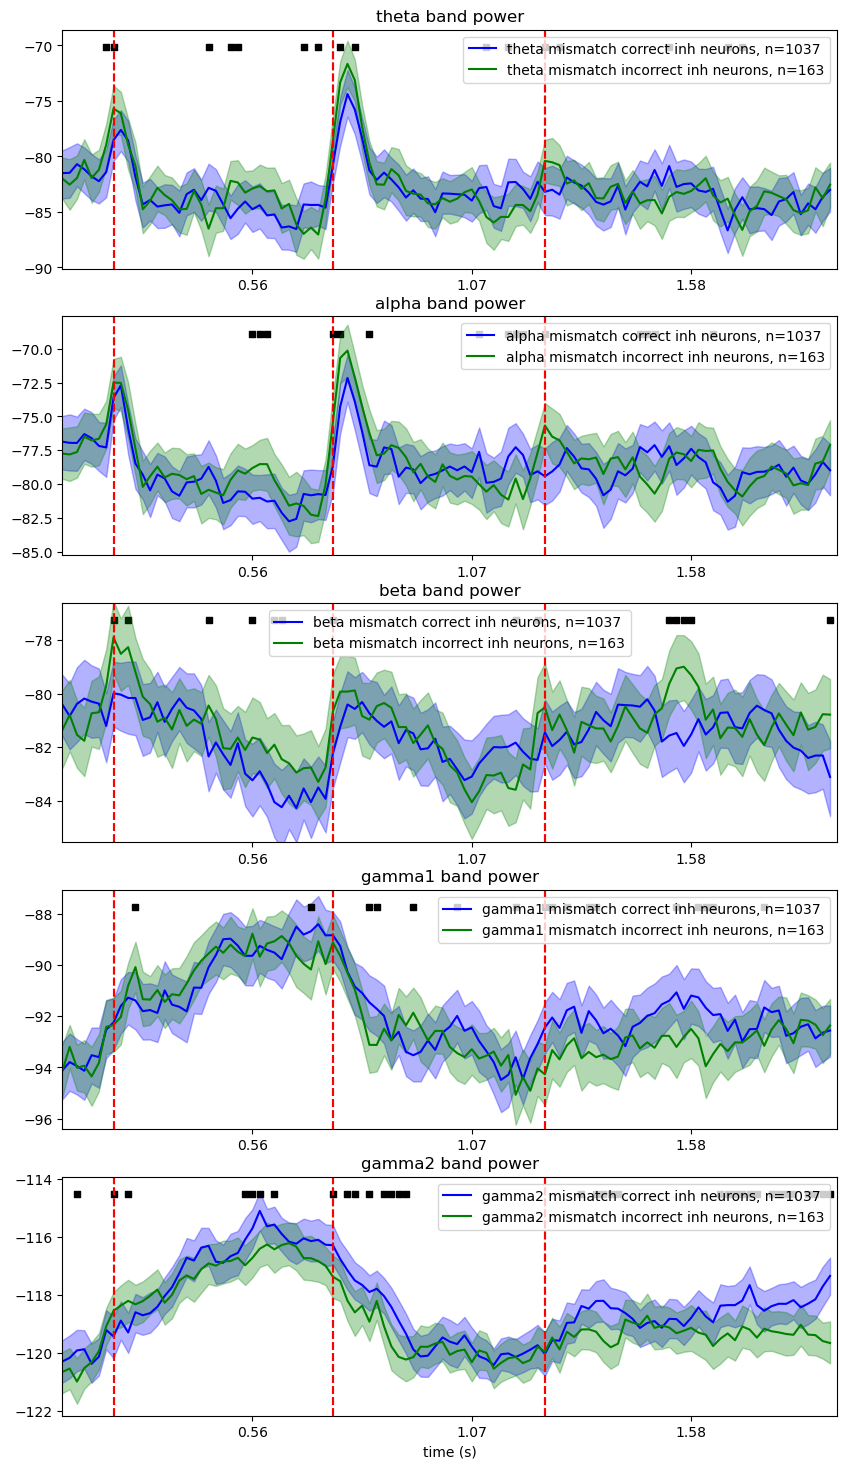

In [39]:
# get mismatch, correct vs incorrect (inh)

importlib.reload(su)

band_avg, band_err, band_pdiff = su.compare_two_spect_groups_bootstrap(f, t, 10*np.log(spect_data[(-1, 1, 'inh')]), 10*np.log(spect_data[(-1, 0, 'inh')]),
            stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, 
            t_skip=30, f_skip=10, 
            neur1_label=f'mismatch correct inh neurons, n={spect_data[(-1,1,"inh")].shape[0]}', 
            neur2_label=f'mismatch incorrect inh neurons, n={spect_data[(-1,0,"inh")].shape[0]}',
            nboot = 1000, CI_int = (2.5, 97.5), random_seed = 820, title=[],
            p_sig = 0.05, band_range = [], time_range = [(stim_on/2)/fs_ds, np.nan])

#### across model code

In [7]:
# get correct and incorrect trials

importlib.reload(su)

# Initialize dictionaries to hold the data for each condition
# spect_data = {}
spect_data = defaultdict(lambda: defaultdict(list))

for i, model_fname in enumerate(model_fnames):
    print(f'Processing {model_fname} ({i+1}/{len(model_fnames)})')

    # Get IPSC filename and load
    # check if file exists first
    if not os.path.isfile(ipsc_dir + f'IPSC_match_correct_delay{delay}_nonorm_{model_fname}'):
        print(f"IPSC file does not exist. Skipping") # {ipsc_dir + f'IPSC_match_correct_delay{delay}_nonorm_{model_fname}'} 
        continue
    model_ipsc_fname = f'IPSC_match_correct_delay{delay}_nonorm_{model_fname}'  # no normalization
    model_ipsc = scipy.io.loadmat(ipsc_dir + model_ipsc_fname)
    perf = np.squeeze(model_ipsc['perf'])
    labels = np.squeeze(model_ipsc['labels'])
    ipscs = model_ipsc['ipscs_all']
    
    fs_ds = 1000

    # Spect params
    nperseg = int(.100*fs_ds) # 100 ms
    noverlap = nperseg // 1.2
    nfft = nperseg * 20

    neur_label = ['exc', 'inh']

    for j, match in enumerate([1, -1]):
        for k, corr in enumerate([1, 0]):
            for l, neur_idx in enumerate([0, 1]): # 0 exc, 1 inh
                ipscs_neur = np.squeeze(ipscs[:,neur_idx,:])
                f, t, s = su.calc_spect(ipscs_neur[(labels == match) & (perf == corr), :], fs_ds, nperseg, noverlap, nfft)
                del ipscs_neur

                if s.shape[0] == 0:
                    print(f"No data for match={match}, corr={corr}, neur = {neur_label[l]}")
                    continue  # Skip to the next iteration if no data is found

                # # save the s in the dictionary
                # spect_data[(match, corr, neur_label[l])]['s'].append(s)

                s_mean = np.nanmean(s, axis=0) # avg over trials
                bandpower, _ = su.calc_band_power(10*np.log(s_mean), f, band='all')
                del s, s_mean

                # Append the computed bandpower to the corresponding lists in the dictionary
                for key in bandpower:
                    spect_data[(match, corr, neur_label[l])][key].append(bandpower[key])
                del bandpower

# Now, we put all spects arrays into the same dictionary with the same keys as before
all_spects = {}

# For each condition (match, corr, exc/inh), stack the bandpower arrays for each key
for key in spect_data:
    all_spects[key] = {}
    for sub_key in spect_data[key]:
        all_spects[key][sub_key] = np.vstack(spect_data[key][sub_key])

# Print the shapes of the all_spects arrays for each key
for key, sub_dict in all_spects.items():
    for sub_key, arr in sub_dict.items():
        print(f"{key} -> {sub_key}: {arr.shape}")


Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_054931.mat (1/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_134828.mat (2/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_205654.mat (3/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_011120.mat (4/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_160950.mat (5/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_05_141900.mat (6/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_05_150729.mat (7/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_025720.mat (8/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_153608.mat (9/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_05_114448.mat (10/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_174646.mat (11/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12

In [9]:
# get timing info
settings = {
    'T': model_ipsc['T'][0][0],
    'delay': model_ipsc['delay'][0][0],
    'stim_on': model_ipsc['stim_on'][0][0]-1, # -1 to make it 0-indexed
    'stim_dur': model_ipsc['stim_dur'][0][0],
    'probe_dur': model_ipsc['probe_dur'][0][0],
}

fs_rate = 200
fs_ds = 1000

T = int(settings['T']/fs_rate*fs_ds)
stim_on = int(settings['stim_on']/fs_rate*fs_ds)
stim_off = int((settings['stim_on'] + settings['stim_dur'])/fs_rate*fs_ds)
probe_on = int((settings['stim_on'] + settings['stim_dur'] + settings['delay'])/fs_rate*fs_ds)
response_on = int((settings['stim_on'] + settings['stim_dur'] + settings['delay'] + 10)/fs_rate*fs_ds)

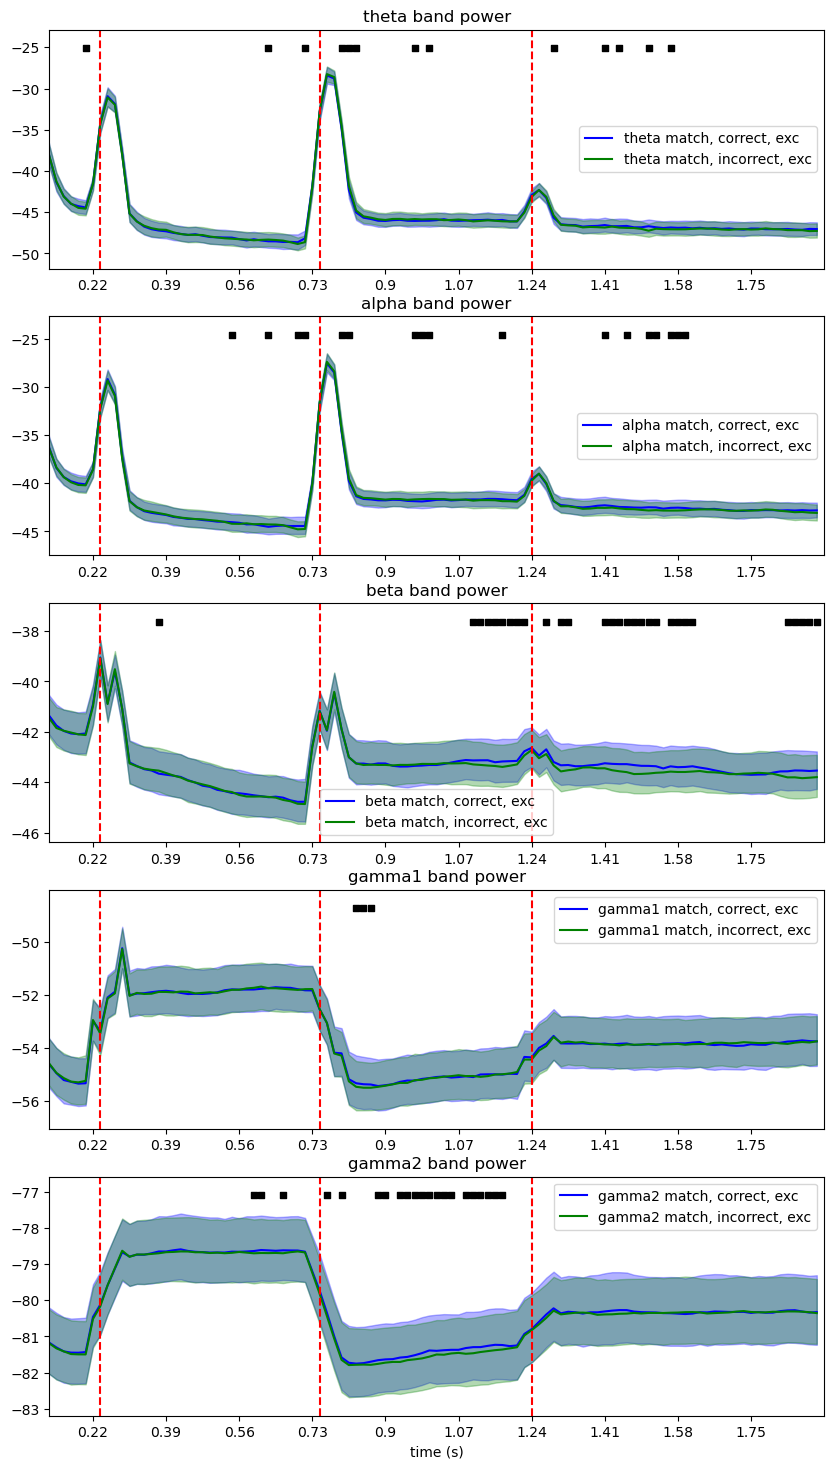

In [10]:
# (match, correct, exc) vs (match, incorrect, exc)
importlib.reload(su)
su.plot_band_power_bootstrap(all_spects[(1, 1, 'exc')], all_spects[(1, 0, 'exc')], t, nboot=1000, CI_int=(2.5, 97.5), random_seed=820,
                              type1_label='match, correct, exc', type2_label='match, incorrect, exc', p_sig=0.05, title = [],
                              stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, t_skip=10,
                              band_range = [], time_range = [(stim_on/2)/fs_ds, np.nan])

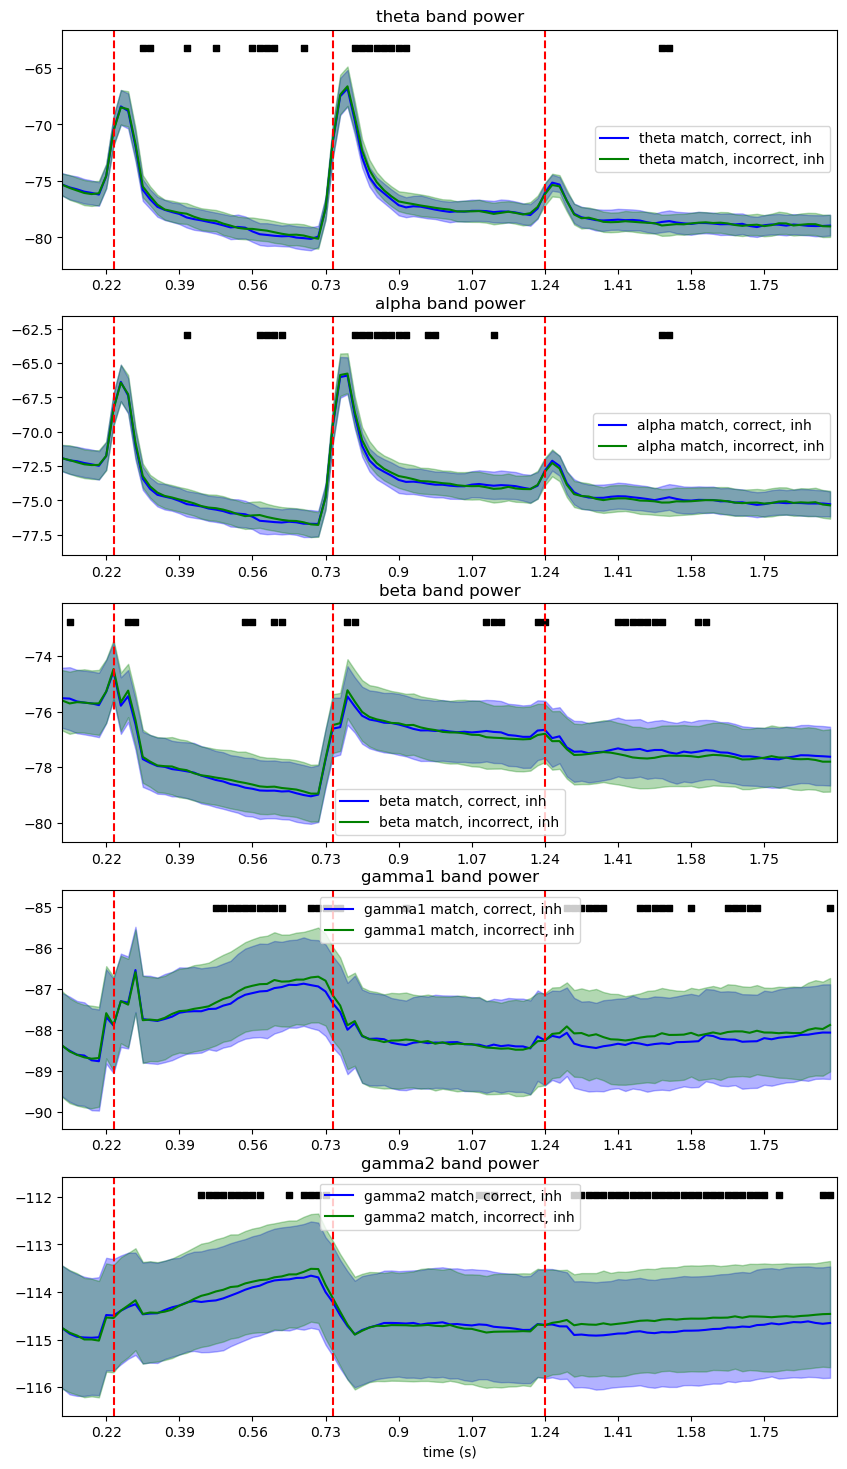

In [11]:
# (match, correct, inh) vs (match, incorrect, inh)
importlib.reload(su)
su.plot_band_power_bootstrap(all_spects[(1, 1, 'inh')], all_spects[(1, 0, 'inh')], t, nboot=1000, CI_int=(2.5, 97.5), random_seed=820,
                              type1_label='match, correct, inh', type2_label='match, incorrect, inh', p_sig=0.05, title = [],
                              stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, t_skip=10,
                              band_range = [], time_range = [(stim_on/2)/fs_ds, np.nan])

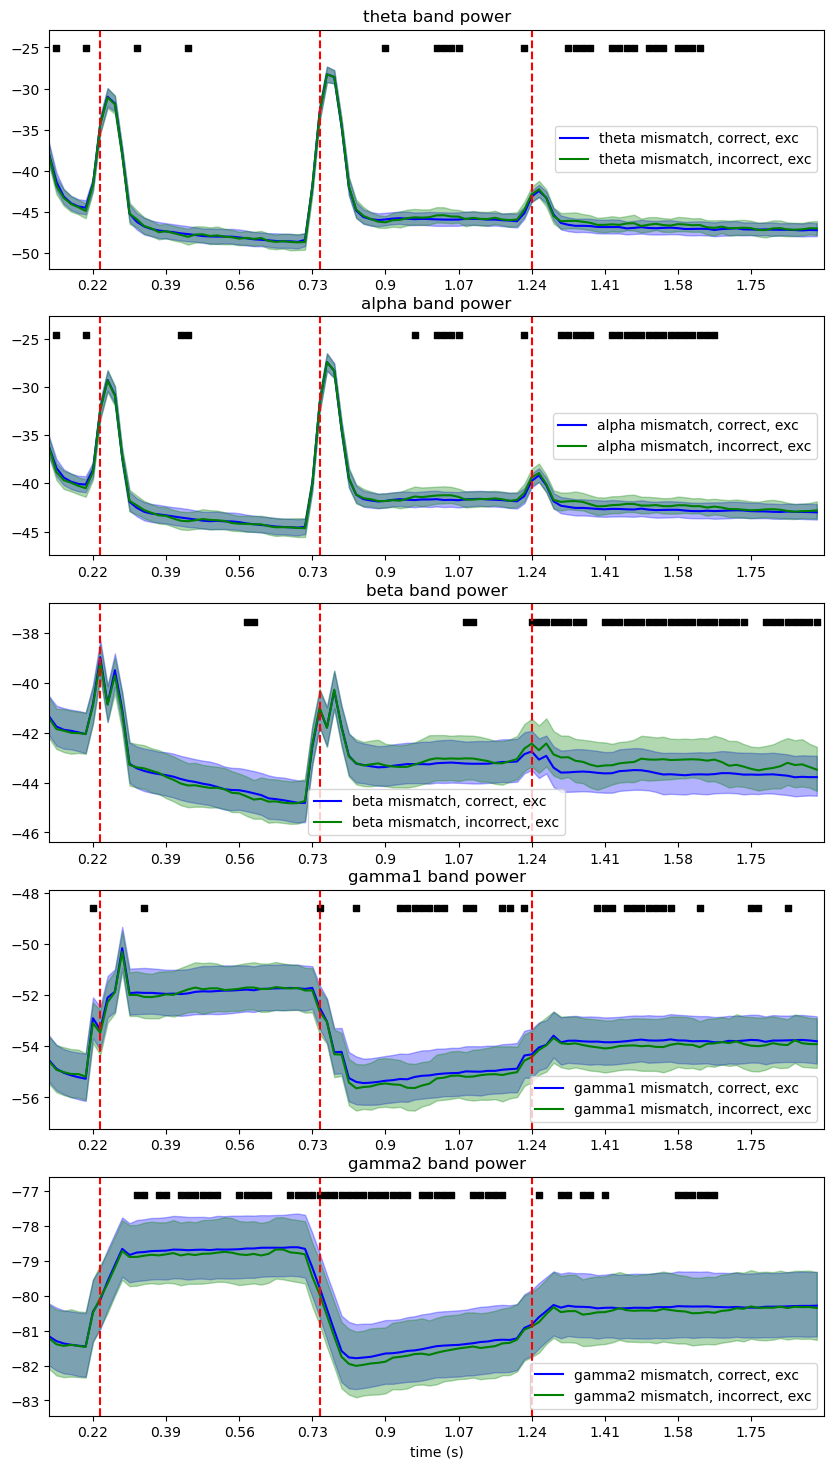

In [12]:
# (mismatch, correct, exc) vs (mismatch, incorrect, exc)
importlib.reload(su)
su.plot_band_power_bootstrap(all_spects[(-1, 1, 'exc')], all_spects[(-1, 0, 'exc')], t, nboot=1000, CI_int=(2.5, 97.5), random_seed=820,
                              type1_label='mismatch, correct, exc', type2_label='mismatch, incorrect, exc', p_sig=0.05, title = [],
                              stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, t_skip=10,
                              band_range = [], time_range = [(stim_on/2)/fs_ds, np.nan])

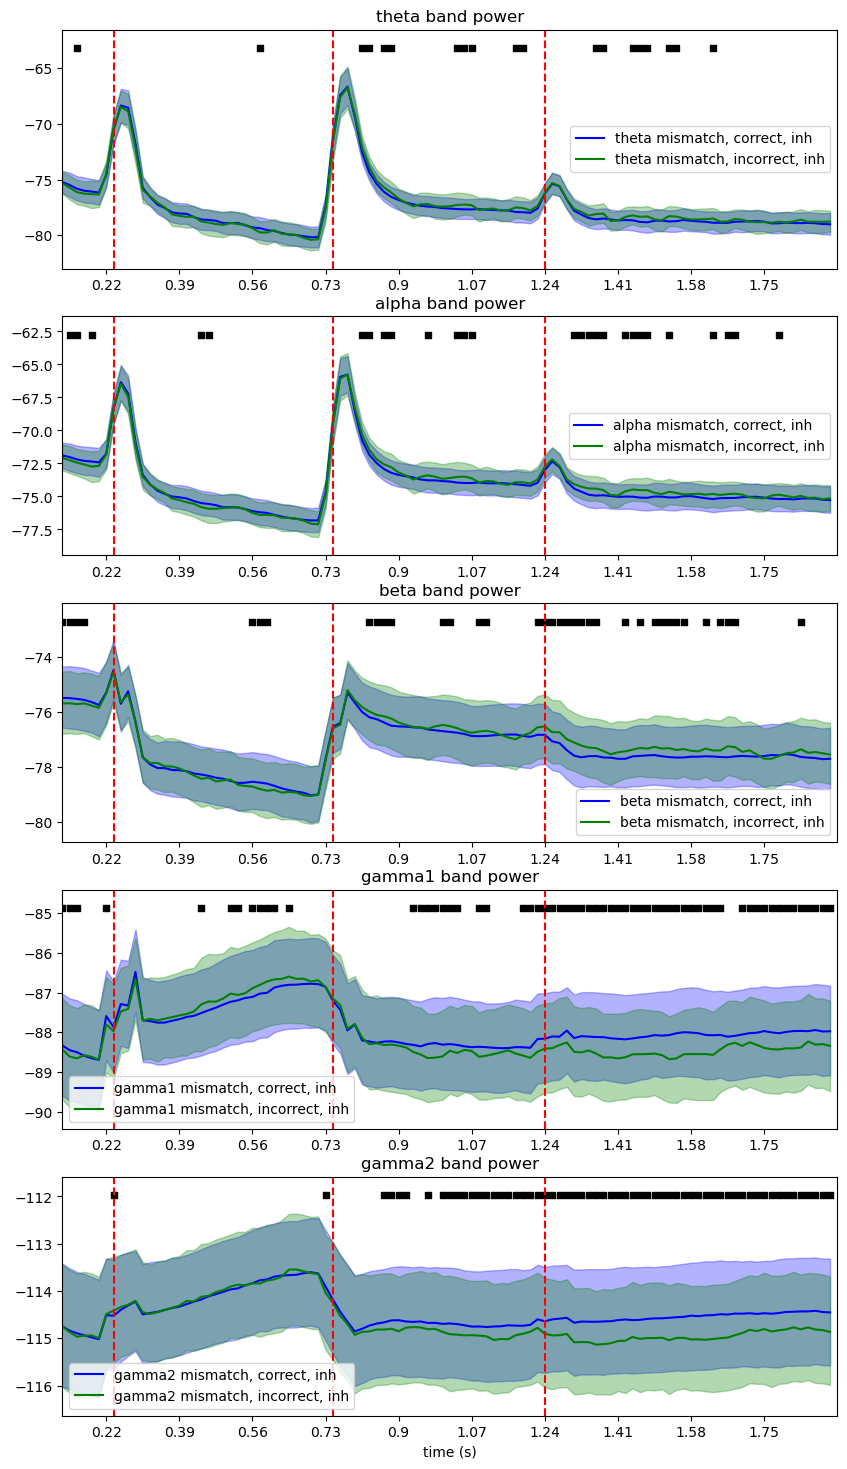

In [13]:
# (mismatch, correct, inh) vs (mismatch, incorrect, inh)
importlib.reload(su)
su.plot_band_power_bootstrap(all_spects[(-1, 1, 'inh')], all_spects[(-1, 0, 'inh')], t, nboot=1000, CI_int=(2.5, 97.5), random_seed=820,
                              type1_label='mismatch, correct, inh', type2_label='mismatch, incorrect, inh', p_sig=0.05, title = [],
                              stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, t_skip=10,
                              band_range = [], time_range = [(stim_on/2)/fs_ds, np.nan])

### Split up by correct vs incorrect (ignoring match vs mismatch)

In [31]:
# get correct and incorrect trials

importlib.reload(su)

# Initialize dictionaries to hold the data for each condition
# spect_data = {}
spect_data = defaultdict(lambda: defaultdict(list))

for i, model_fname in enumerate(model_fnames):
    print(f'Processing {model_fname} ({i+1}/{len(model_fnames)})')

    # Get IPSC filename and load
    model_ipsc_fname = f'IPSC_match_correct_delay{delay}_nonorm_{model_fname}'  # no normalization
    model_ipsc = scipy.io.loadmat(ipsc_dir + model_ipsc_fname)
    perf = np.squeeze(model_ipsc['perf'])
    labels = np.squeeze(model_ipsc['labels'])
    ipscs = model_ipsc['ipscs_all']
    
    fs_ds = 1000

    # Spect params
    nperseg = int(.100*fs_ds) # 100 ms
    noverlap = nperseg // 1.2
    nfft = nperseg * 20

    neur_label = ['exc', 'inh']

    for k, corr in enumerate([1, 0]):
        for l, neur_idx in enumerate([0, 1]): # 0 exc, 1 inh
            ipscs_neur = np.squeeze(ipscs[:,neur_idx,:])
            f, t, s = su.calc_spect(ipscs_neur[perf == corr, :], fs_ds, nperseg, noverlap, nfft)
            s = 10*np.log(s)
            del ipscs_neur

            if s.shape[0] == 0:
                print(f"No data for corr={corr}, neur = {neur_label[l]}")
                continue  # Skip to the next iteration if no data is found

            bandpower, _ = su.calc_band_power(np.nanmean(s, axis=0), f, band='all') # avg over trials
            del s

            # Append the computed bandpower to the corresponding lists in the dictionary
            for key in bandpower:
                spect_data[(corr, neur_label[l])][key].append(bandpower[key])
            del bandpower

# Now, we put all spects arrays into the same dictionary with the same keys as before
all_spects = {}

# For each condition (corr, exc/inh), stack the bandpower arrays for each key
for key in spect_data:
    all_spects[key] = {}
    for sub_key in spect_data[key]:
        all_spects[key][sub_key] = np.vstack(spect_data[key][sub_key])
        print(f"{key} -> {sub_key}: {arr.shape}")

Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_054931.mat (1/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_134828.mat (2/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_205654.mat (3/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_011120.mat (4/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_160950.mat (5/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_05_141900.mat (6/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_05_150729.mat (7/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_025720.mat (8/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_153608.mat (9/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_05_114448.mat (10/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_174646.mat (11/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12

In [16]:
# get timing info
settings = {
    'T': model_ipsc['T'][0][0],
    'delay': model_ipsc['delay'][0][0],
    'stim_on': model_ipsc['stim_on'][0][0]-1, # -1 to make it 0-indexed
    'stim_dur': model_ipsc['stim_dur'][0][0],
    'probe_dur': model_ipsc['probe_dur'][0][0],
}

fs_rate = 200
fs_ds = 1000

T = int(settings['T']/fs_rate*fs_ds)
stim_on = int(settings['stim_on']/fs_rate*fs_ds)
stim_off = int((settings['stim_on'] + settings['stim_dur'])/fs_rate*fs_ds)
probe_on = int((settings['stim_on'] + settings['stim_dur'] + settings['delay'])/fs_rate*fs_ds)
response_on = int((settings['stim_on'] + settings['stim_dur'] + settings['delay'] + 10)/fs_rate*fs_ds)

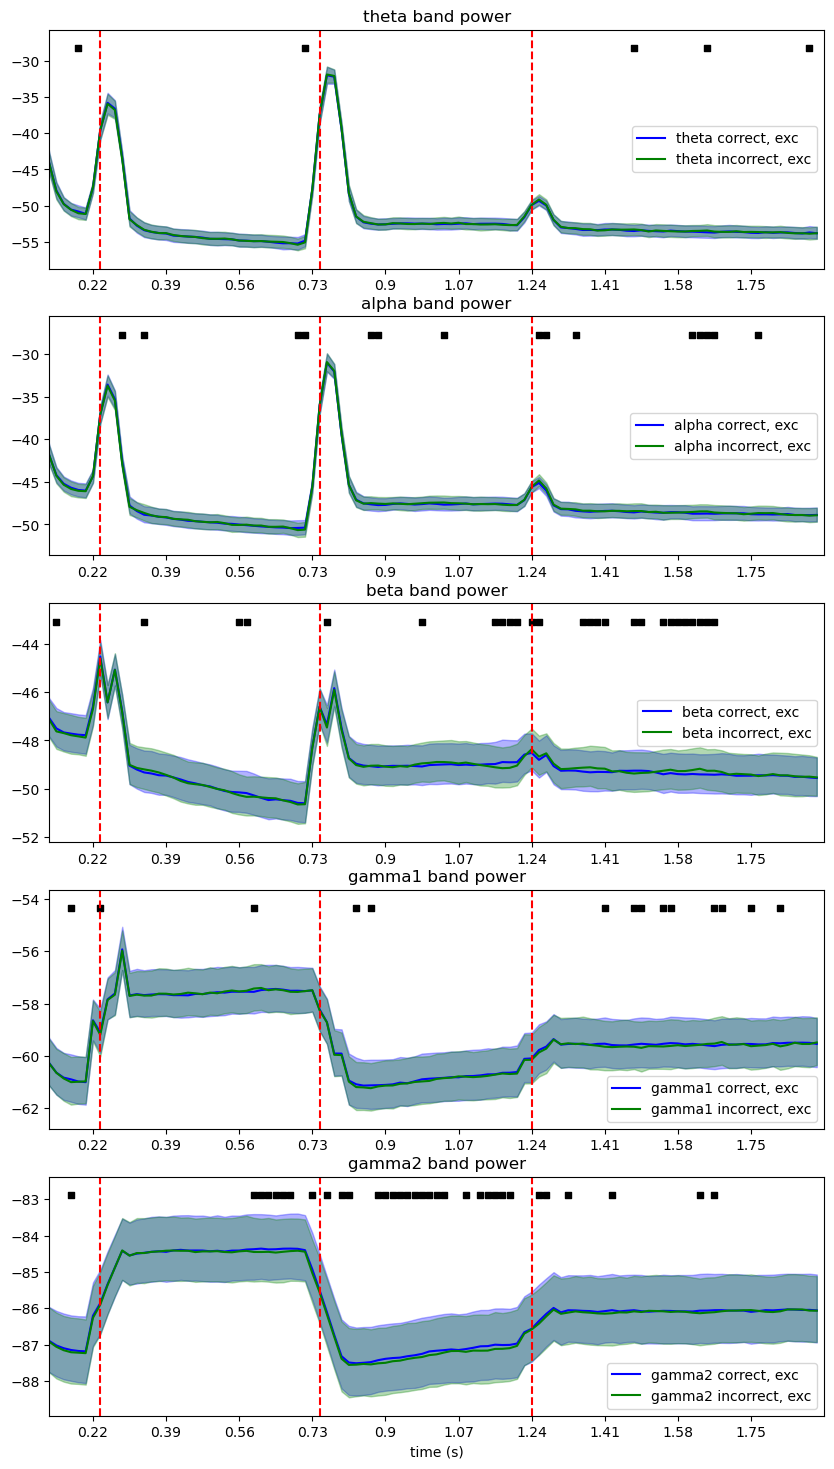

In [32]:
# (correct, exc) vs (incorrect, exc)
importlib.reload(su)
su.plot_band_power_bootstrap(all_spects[(1, 'exc')], all_spects[(0, 'exc')], t, nboot=1000, CI_int=(2.5, 97.5), random_seed=820,
                              type1_label='correct, exc', type2_label='incorrect, exc', p_sig=0.05, title = [],
                              stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, t_skip=10,
                              band_range = [], time_range = [(stim_on/2)/fs_ds, np.nan])

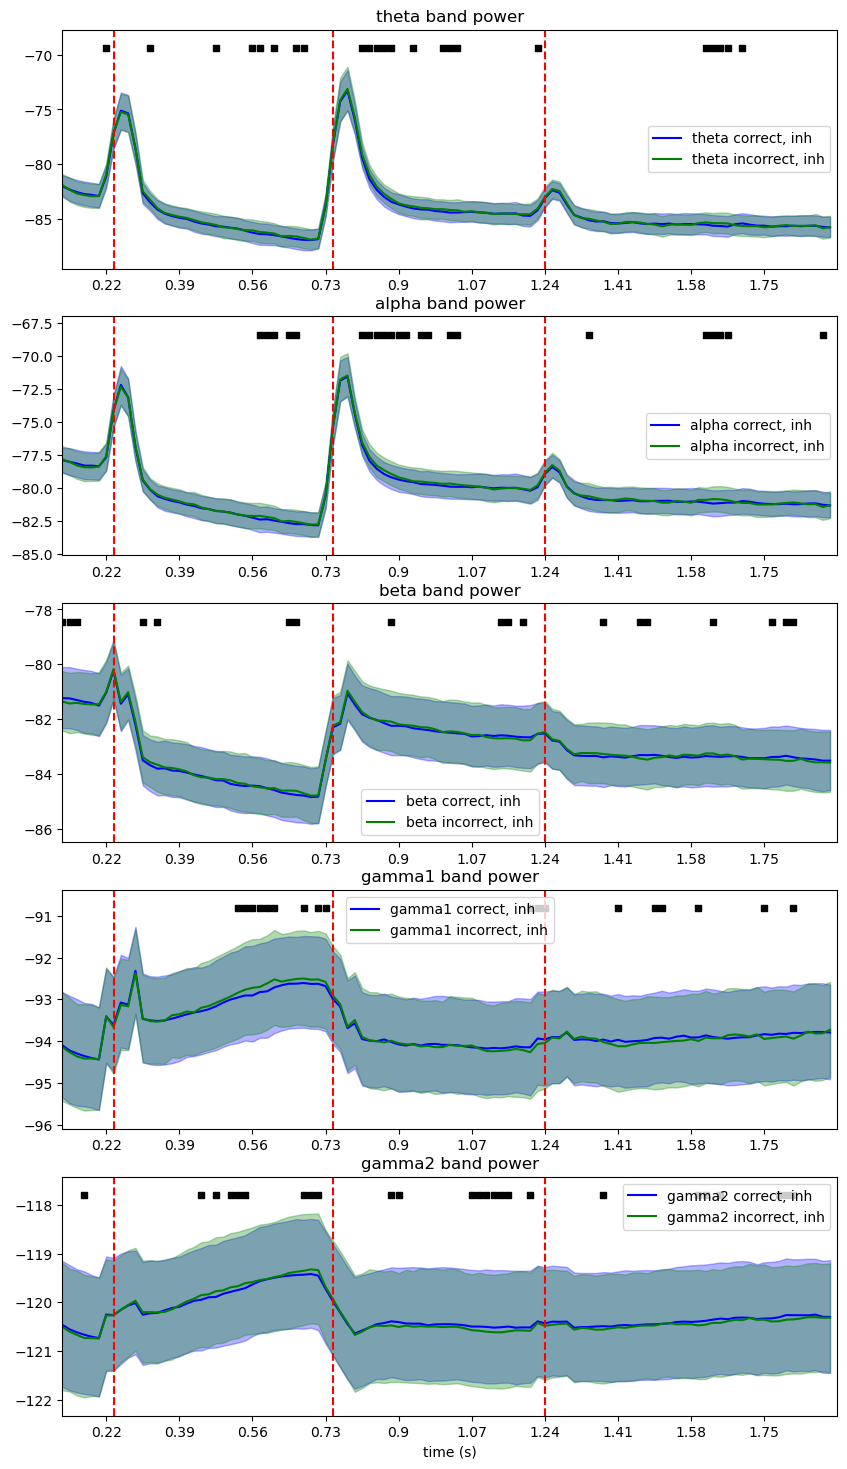

In [33]:
# (correct, inh) vs (incorrect, inh)
importlib.reload(su)
su.plot_band_power_bootstrap(all_spects[(1, 'inh')], all_spects[(0, 'inh')], t, nboot=1000, CI_int=(2.5, 97.5), random_seed=820,
                              type1_label='correct, inh', type2_label='incorrect, inh', p_sig=0.05, title = [],
                              stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, t_skip=10,
                              band_range = [], time_range = [(stim_on/2)/fs_ds, np.nan])

## Recalculating with other bootstrapping method

### Split up by correct vs incorrect (ignoring match vs mismatch)

In [28]:
# get correct and incorrect trials

importlib.reload(su)

# Initialize dictionaries to hold the data for each condition
# spect_data = {}
spect_data = defaultdict(lambda: defaultdict(list))

for i, model_fname in enumerate(model_fnames):
    print(f'Processing {model_fname} ({i+1}/{len(model_fnames)})')

    # Get IPSC filename and load
    model_ipsc_fname = f'IPSC_match_correct_delay{delay}_nonorm_{model_fname}'  # no normalization
    model_ipsc = scipy.io.loadmat(ipsc_dir + model_ipsc_fname)
    perf = np.squeeze(model_ipsc['perf'])
    labels = np.squeeze(model_ipsc['labels'])
    ipscs = model_ipsc['ipscs_all']
    
    fs_ds = 1000

    # Spect params
    nperseg = int(.100*fs_ds) # 100 ms
    noverlap = nperseg // 1.2
    nfft = nperseg * 20

    neur_label = ['exc', 'inh']

    for l, neur_idx in enumerate([0, 1]):
        ipscs_neur = ipscs[:,neur_idx,:]
        f, t, s = su.calc_spect(ipscs_neur, fs_ds, nperseg, noverlap, nfft)
        s = 10*np.log(s) # convert to dB
        s_corr = s[perf == 1, :]
        s_incorr = s[perf == 0, :]
        bandpower_bootstrap,_,_ = su.calc_band_power_bootstrap(s_corr, s_incorr, f, nboot=1000, CI_int=(2.5, 97.5), random_seed=820)

        for k, corr in enumerate([1, 0]):
            # Append the computed bandpower to the corresponding lists in the dictionary
            for key in bandpower_bootstrap:
                spect_data[(corr, neur_label[l])][key].append(np.nanmean(bandpower_bootstrap[key][corr], axis=1))

# Now, we put all spects arrays into the same dictionary with the same keys as before
all_spects = {}

# For each condition (corr, exc/inh), stack the bandpower arrays for each key
for key in spect_data:
    all_spects[key] = {}
    for sub_key in spect_data[key]:
        all_spects[key][sub_key] = np.vstack(spect_data[key][sub_key])
        print(f"{key} -> {sub_key}: {arr.shape}")

Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_054931.mat (1/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_134828.mat (2/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_205654.mat (3/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_011120.mat (4/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_160950.mat (5/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_05_141900.mat (6/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_05_150729.mat (7/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_025720.mat (8/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_153608.mat (9/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_05_114448.mat (10/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_174646.mat (11/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12

In [ ]:
# get timing info
settings = {
    'T': model_ipsc['T'][0][0],
    'delay': model_ipsc['delay'][0][0],
    'stim_on': model_ipsc['stim_on'][0][0]-1, # -1 to make it 0-indexed
    'stim_dur': model_ipsc['stim_dur'][0][0],
    'probe_dur': model_ipsc['probe_dur'][0][0],
}

fs_rate = 200
fs_ds = 1000

T = int(settings['T']/fs_rate*fs_ds)
stim_on = int(settings['stim_on']/fs_rate*fs_ds)
stim_off = int((settings['stim_on'] + settings['stim_dur'])/fs_rate*fs_ds)
probe_on = int((settings['stim_on'] + settings['stim_dur'] + settings['delay'])/fs_rate*fs_ds)
response_on = int((settings['stim_on'] + settings['stim_dur'] + settings['delay'] + 10)/fs_rate*fs_ds)

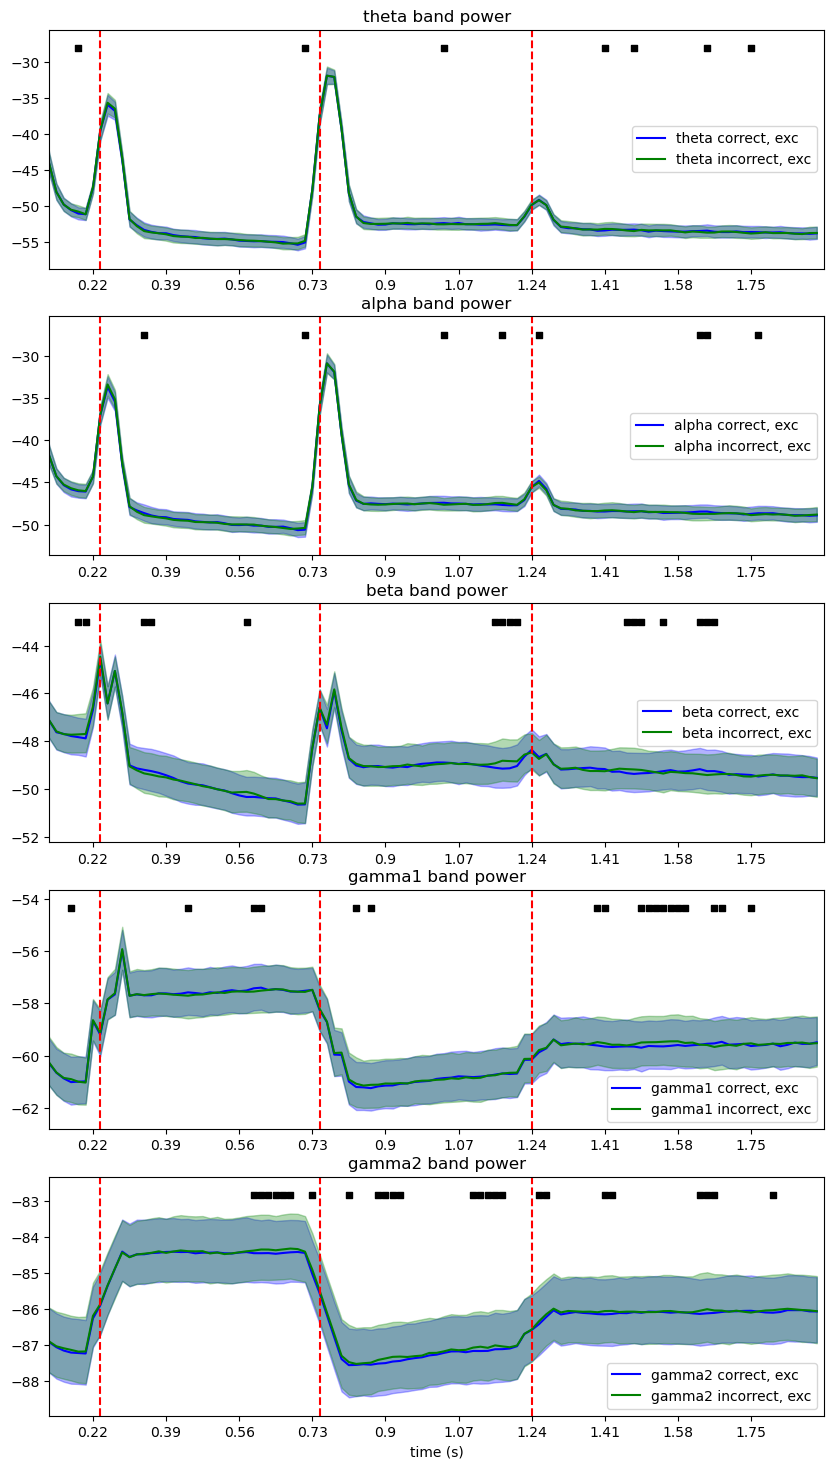

In [29]:
# (correct, exc) vs (incorrect, exc)
importlib.reload(su)
su.plot_band_power_bootstrap(all_spects[(1, 'exc')], all_spects[(0, 'exc')], t, nboot=1000, CI_int=(2.5, 97.5), random_seed=820,
                              type1_label='correct, exc', type2_label='incorrect, exc', p_sig=0.05, title = [],
                              stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, t_skip=10,
                              band_range = [], time_range = [(stim_on/2)/fs_ds, np.nan])

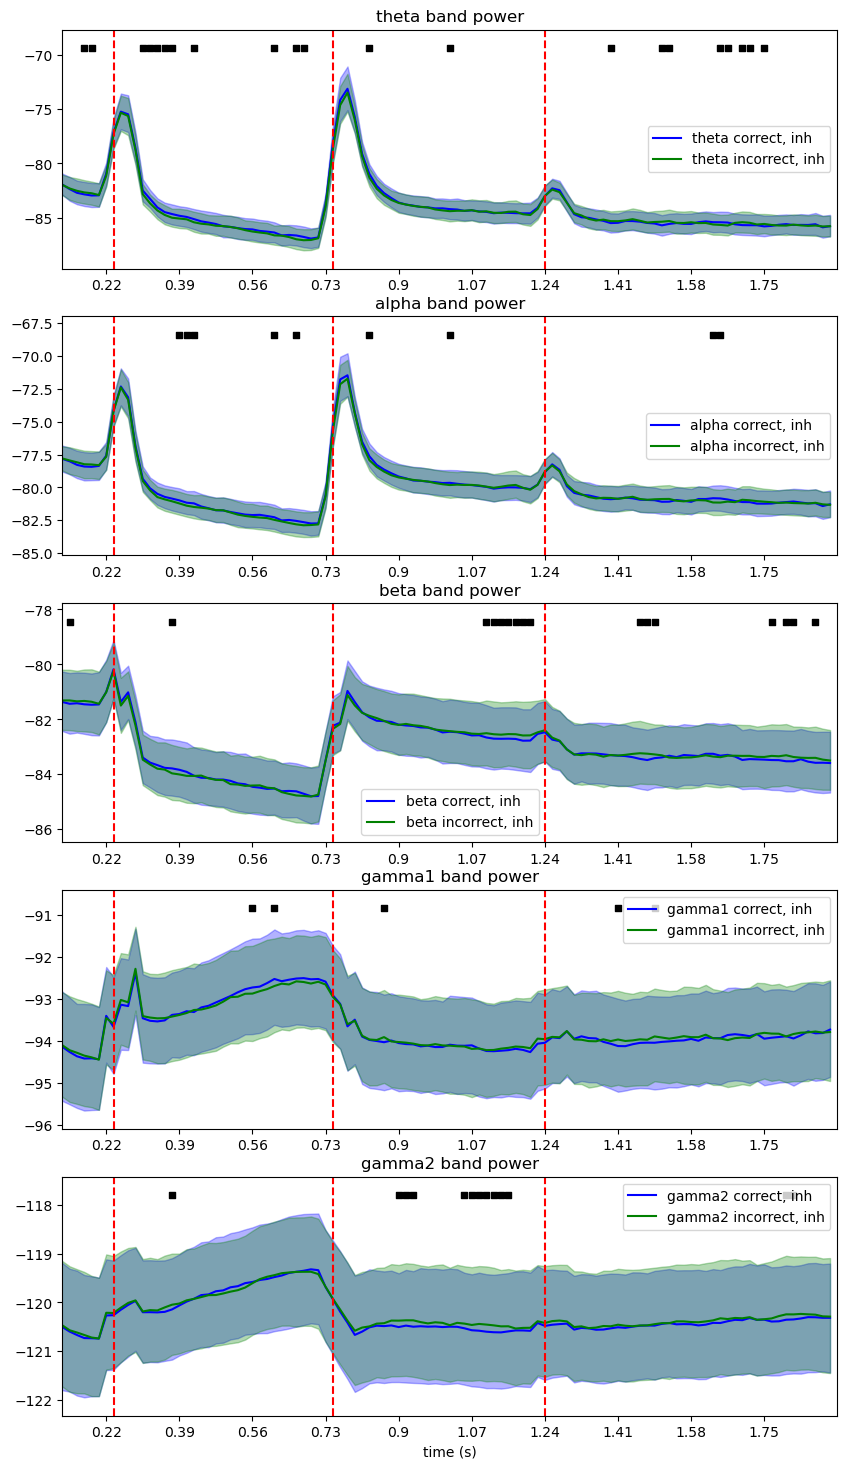

In [30]:
# (correct, inh) vs (incorrect, inh)
importlib.reload(su)
su.plot_band_power_bootstrap(all_spects[(1, 'inh')], all_spects[(0, 'inh')], t, nboot=1000, CI_int=(2.5, 97.5), random_seed=820,
                              type1_label='correct, inh', type2_label='incorrect, inh', p_sig=0.05, title = [],
                              stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, t_skip=10,
                              band_range = [], time_range = [(stim_on/2)/fs_ds, np.nan])